In [20]:
from torchvision.transforms import Compose, Resize, ToTensor, Normalize, ConvertImageDtype
from torch import nn
from torchvision.models import resnet50
from torchvision import datasets
from torch.utils.data import DataLoader
from tqdm import tqdm
from pathlib import Path
import gc
import sys

import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [6]:
DATA_DIR = Path('../data/10monkeys/archive')
IMG_SIZE = (224, 224)


class MonkeyDataset(datasets.ImageFolder):
    def __init__(self, mode, transform=None):

        root = DATA_DIR / "training" if mode == 'train' else DATA_DIR / "validation"

        super().__init__(root=root, transform=transform)
        self.targets = [_[1] for _ in self.samples]

# 计算数据的 mean 和 std


def compute_mean_std(dataset):
    loader = DataLoader(dataset, batch_size=64, shuffle=False)

    mean = 0.0
    std = 0.0
    total_images = 0

    for images, _ in tqdm(loader, desc="Computing mean/std"):
        # batch size (the last batch can have smaller size)
        batch_samples = images.size(0)
        # reshape to (batch_size, channels, width*height)
        images = images.view(batch_samples, images.size(1), -1)
        mean += images.mean(2).sum(0)  # sum of means for each channel
        std += images.std(2).sum(0)  # sum of stds for each channel
        total_images += batch_samples

    mean /= total_images
    std /= total_images

    return mean.tolist(), std.tolist()


mean, std = compute_mean_std(
    MonkeyDataset(mode='train', transform=Compose([
        Resize(IMG_SIZE),
        ToTensor(),
    ])))

transform = Compose([
    Resize(IMG_SIZE),
    ToTensor(),
    Normalize(mean=mean, std=std),
    ConvertImageDtype(torch.float32)
])

train_ds = MonkeyDataset(mode='train', transform=transform)
val_ds = MonkeyDataset(mode='validation', transform=transform)

Computing mean/std: 100%|██████████| 18/18 [00:13<00:00,  1.33it/s]


In [7]:
batch_size = 128
num_workers = 0
train_loader = DataLoader(
    train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(
    val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)

In [18]:
class ResNet50(nn.Module):
    def __init__(self, num_classes: int = 10, frozen: bool = True):
        super().__init__()
        self.model = resnet50(weights='IMAGENET1K_V2')
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)
        if frozen:
            for param in self.model.parameters():
                param.requires_grad = False

    def forward(self, x):
        return self.model(x)


print('冻结参数', sum(p.numel() for p in ResNet50().parameters()))
print('未冻结参数', sum(p.numel()
      for p in ResNet50().parameters() if p.requires_grad))

冻结参数 23528522
未冻结参数 0


In [19]:
# 微调大模型
class ResNet50(nn.Module):
    def __init__(self, num_classes: int = 10, frozen: bool = True):
        super().__init__()
        self.model = resnet50(weights='IMAGENET1K_V2')
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)
        if frozen:
            for param in self.model.parameters():
                param.requires_grad = False
            # 只训练最后一层
            for param in self.model.fc.parameters():
                param.requires_grad = True

    def forward(self, x):
        return self.model(x)


print('冻结参数', sum(p.numel() for p in ResNet50().parameters()))
print('未冻结参数', sum(p.numel()
      for p in ResNet50().parameters() if p.requires_grad))

冻结参数 23528522
未冻结参数 20490


Epoch 1/20 | train_loss=2.0786 | train_acc=0.4558 | train_balanced_acc=0.4544 | train_f1_macro=0.4574 | val_loss=1.8837 | val_acc=0.8199 | val_balanced_acc=0.8165 | val_f1_macro=0.8115 | lr=0.0010 | epoch_seconds=18.3162


Epoch 2/20 | train_loss=1.4928 | train_acc=0.9116 | train_balanced_acc=0.9101 | train_f1_macro=0.9102 | val_loss=1.3539 | val_acc=0.9596 | val_balanced_acc=0.9595 | val_f1_macro=0.9587 | lr=0.0010 | epoch_seconds=17.6385


Epoch 3/20 | train_loss=1.0713 | train_acc=0.9654 | train_balanced_acc=0.9649 | train_f1_macro=0.9651 | val_loss=0.9909 | val_acc=0.9632 | val_balanced_acc=0.9632 | val_f1_macro=0.9627 | lr=0.0010 | epoch_seconds=18.1973


Epoch 4/20 | train_loss=0.7729 | train_acc=0.9790 | train_balanced_acc=0.9789 | train_f1_macro=0.9789 | val_loss=0.7490 | val_acc=0.9669 | val_balanced_acc=0.9668 | val_f1_macro=0.9663 | lr=0.0010 | epoch_seconds=18.0771


Epoch 5/20 | train_loss=0.5835 | train_acc=0.9809 | train_balanced_acc=0.9807 | train_f1_macro=0.9808 | val_loss=0.5981 | val_acc=0.9743 | val_balanced_acc=0.9743 | val_f1_macro=0.9737 | lr=0.0010 | epoch_seconds=18.1824


...

Epoch 16/20 | train_loss=0.1169 | train_acc=0.9982 | train_balanced_acc=0.9982 | train_f1_macro=0.9982 | val_loss=0.1932 | val_acc=0.9853 | val_balanced_acc=0.9856 | val_f1_macro=0.9850 | lr=0.0010 | epoch_seconds=18.2012


Epoch 17/20 | train_loss=0.1059 | train_acc=1.0000 | train_balanced_acc=1.0000 | train_f1_macro=1.0000 | val_loss=0.1833 | val_acc=0.9853 | val_balanced_acc=0.9856 | val_f1_macro=0.9850 | lr=0.0010 | epoch_seconds=18.1991


Epoch 18/20 | train_loss=0.0987 | train_acc=0.9991 | train_balanced_acc=0.9991 | train_f1_macro=0.9991 | val_loss=0.1741 | val_acc=0.9853 | val_balanced_acc=0.9856 | val_f1_macro=0.9850 | lr=0.0010 | epoch_seconds=18.1562


Epoch 19/20 | train_loss=0.0903 | train_acc=1.0000 | train_balanced_acc=1.0000 | train_f1_macro=1.0000 | val_loss=0.1667 | val_acc=0.9853 | val_balanced_acc=0.9856 | val_f1_macro=0.9850 | lr=0.0010 | epoch_seconds=18.1913


Epoch 20/20 | train_loss=0.0857 | train_acc=1.0000 | train_balanced_acc=1.0000 | train_f1_macro=1.0000 | val_loss=0.1615 | val_acc=0.9853 | val_balanced_acc=0.9856 | val_f1_macro=0.9850 | lr=0.0010 | epoch_seconds=18.1577


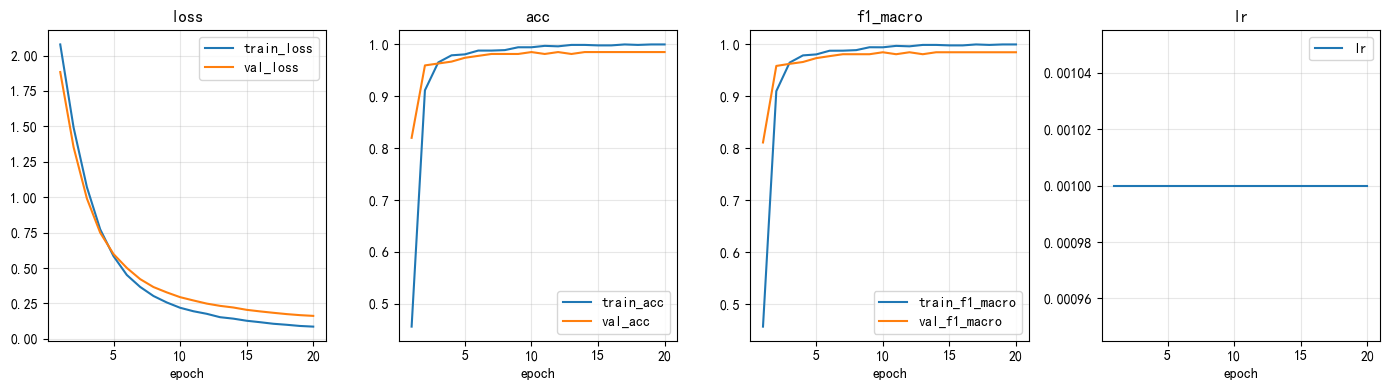

In [22]:
gc.collect()
torch.cuda.empty_cache()

project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
from base import TorchTrainer, ReduceLROnPlateau


model = ResNet50(num_classes=10).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

trainer = TorchTrainer(
    model=model,
    criterion=loss_fn,
    optimizer=optimizer,
    scheduler=scheduler,
    scheduler_step="plateau",
    monitor="val_loss",
    mode="min",
    patience=5,
    device=device,
    amp=True,
    checkpoint_dir="./checkpoints/resnet50_10monkeys"
)

trainer.fit(train_loader, val_loader, epochs=20)
trainer.plot_history()